In [22]:
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')
import numpy as np
from sklearn.datasets._samples_generator import make_blobs

X, y = make_blobs(n_samples=15, centers=3, n_features=2)

# X = np.array([[1,2],
#               [1.5, 1.8],
#               [5, 8],
#               [8,8],
#               [1, 0.6],
#               [9,11],
#               [8,2],
#               [10,2],
#               [9,3],])



# plt.scatter(X[:,0],X[:,1], s=150, linewidths=5)
# plt.show()

colors = ['g','r','c','b','k']

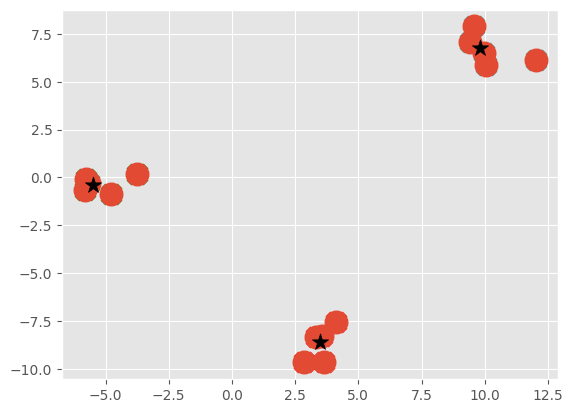

In [23]:
class Mean_Shift:
    def __init__(self, radius=None, radius_norm_step = 100):
        self.radius = radius
        self.radius_norm_step = radius_norm_step


    def fit(self, data):

        if self.radius == None:
            all_data_centroid = np.average(data, axis=0)
            all_data_norm = np.linalg.norm(all_data_centroid)
            self.radius = all_data_norm / self.radius_norm_step


        centroids = {i: data[i] for i in range(len(data))}
        
        while True:
            new_centroids = []
            for i in centroids:
                in_bandwidth = []
                centroid = centroids[i]

                weights = [i for i in range(self.radius_norm_step)][::-1]
                for featureset in data:
                    distance = np.linalg.norm(featureset-centroid)
                    if distance == 0:
                        distance = 0.000000001
                    weights_index = int(distance/self.radius)
                    if weights_index > self.radius_norm_step - 1 :
                        weights_index = self.radius_norm_step - 1
                    to_add = (weights[weights_index]**2)*[featureset]
                    in_bandwidth += to_add


                if in_bandwidth:
                    new_centroid = np.average(in_bandwidth, axis=0)
                else:
                    new_centroid = centroid  # No points in bandwidth
                
                new_centroids.append(tuple(new_centroid))
            
            uniques = sorted(list(set(new_centroids)))


            to_pop = []
            
            for i in uniques:
                for ii in uniques:
                    if i == ii:
                        pass
                    elif np.linalg.norm(np.array(i) - np.array(ii)) <= self.radius:
                        to_pop.append(ii)
                        break
            
            for i in to_pop:
                try:
                    uniques.remove(i)
                except:
                    pass
            
            prev_centroids = centroids.copy()
            centroids = {i: np.array(uniques[i]) for i in range(len(uniques))}
            
            optimized = True
            for i in centroids:
                if not np.array_equal(centroids[i], prev_centroids.get(i)):
                    optimized = False
                    break
            
            if optimized:
                break

        self.centroids = centroids


        self.classifications = {}

        for i in range(len(self.centroids)):
            self.classifications[i] = []

        for featureset in data:
            distances = [np.linalg.norm(featureset - self.centroids[centroid]) for centroid in self.centroids]
            classification = distances.index(min(distances))
            self.classifications[classification].append(featureset)
        

    def predict(self, data):
        distances = [np.linalg.norm(featureset - self.centroids[centroid]) for centroid in self.centroids]
        classification = distances.index(min(distances))
        return classification

# Fit the Mean Shift model
clf = Mean_Shift()
clf.fit(X)

# Extract centroids
centroids = clf.centroids


for classification in clf.classifications:
    color = colors[classification]
    for featureset in clf.classifications[classification]:
        plt.scatter(featureset[0],featureset[1], marker='x', color = color, s=150, linewidths=5 )
# Plot data and centroids
plt.scatter(X[:, 0], X[:, 1], s=150, linewidths=5)
for c in centroids:
    plt.scatter(centroids[c][0], centroids[c][1], s=150, color='k', marker='*')
plt.show()